In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Kelas F_Student AI Usage.csv to Kelas F_Student AI Usage.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])

In [ ]:
df.head()

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


In [ ]:
print(df.columns)

Index(['age', 'education_level', 'study_hours_per_day', 'uses_ai',
       'ai_tools_used', 'purpose_of_ai', 'grades_before_ai', 'grades_after_ai',
       'daily_screen_time_hours'],
      dtype='object')


In [ ]:
#soal a
std_edu = (
    df.groupby('education_level')['grades_after_ai']
    .std()
    .reset_index()
)

print(std_edu)

  education_level  grades_after_ai
0         college         7.679299
1          school         8.614853


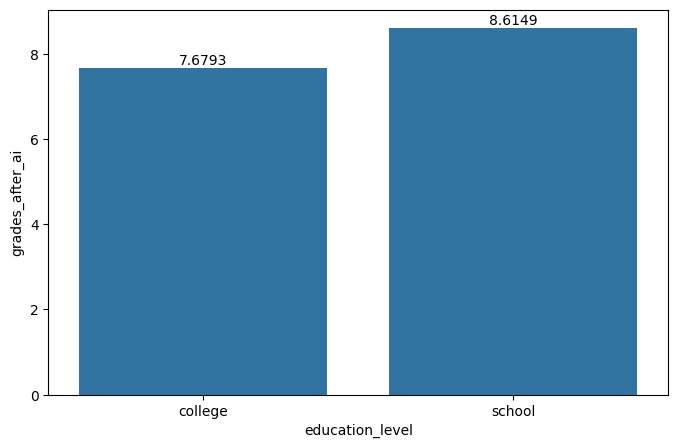

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=std_edu,
    x='education_level',
    y='grades_after_ai',
    ax=ax
)

for i, v in enumerate(std_edu['grades_after_ai']):
    ax.text(
        i,
        v,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
#tugas b
college_high = df[
    (df['education_level'] == 'college') &
    (df['grades_after_ai'] > 80)
]

In [ ]:
hasil_b = (
    college_high.groupby('age')
    .size()
    .reset_index(name='jumlah')
)

print(hasil_b)

   age  jumlah
0   17       1
1   18       1
2   19       1


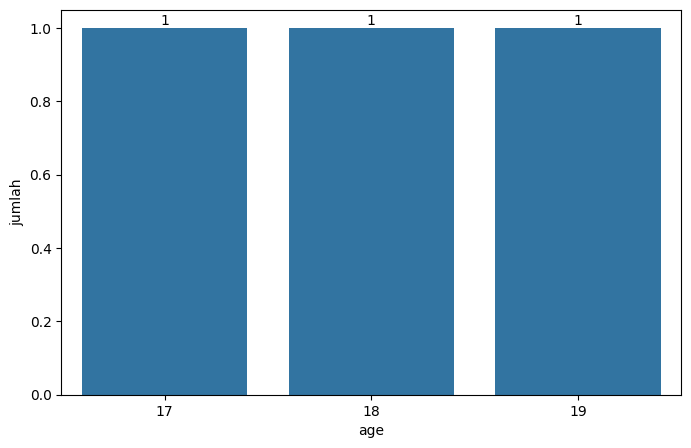

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=hasil_b,
    x='age',
    y='jumlah',
    ax=ax
)

for i, v in enumerate(hasil_b['jumlah']):
    ax.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
#tugas c
df['improvement'] = (
    df['grades_after_ai']
    - df['grades_before_ai']
)

In [ ]:
corr = df['age'].corr(df['improvement'])

print("Nilai Korelasi =", corr)

Nilai Korelasi = 0.039463880095200604


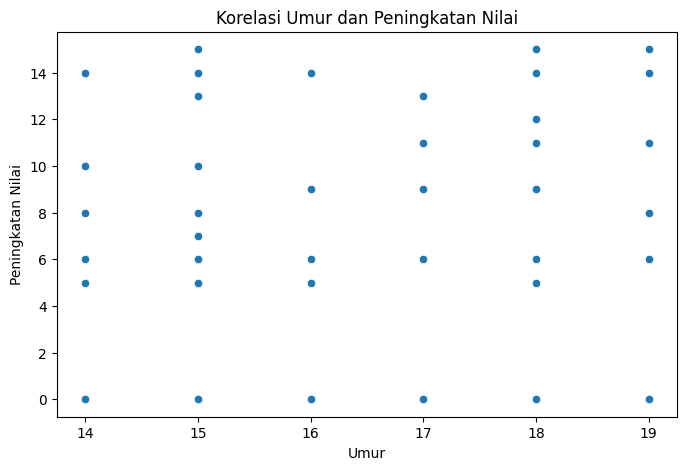

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='age',
    y='improvement',
    ax=ax
)

ax.set_title('Korelasi Umur dan Peningkatan Nilai')
ax.set_xlabel('Umur')
ax.set_ylabel('Peningkatan Nilai')

plt.show()

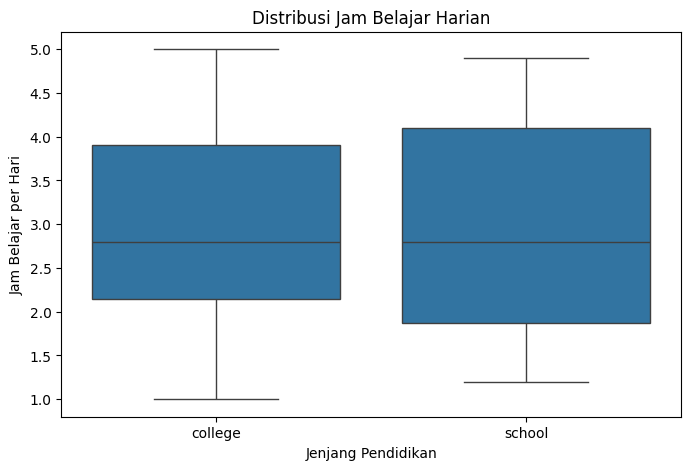

In [ ]:
#Study hours berdasarkan education level
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=df,
    x='education_level',
    y='study_hours_per_day',
    ax=ax
)

ax.set_title('Distribusi Jam Belajar Harian')
ax.set_xlabel('Jenjang Pendidikan')
ax.set_ylabel('Jam Belajar per Hari')

plt.show()

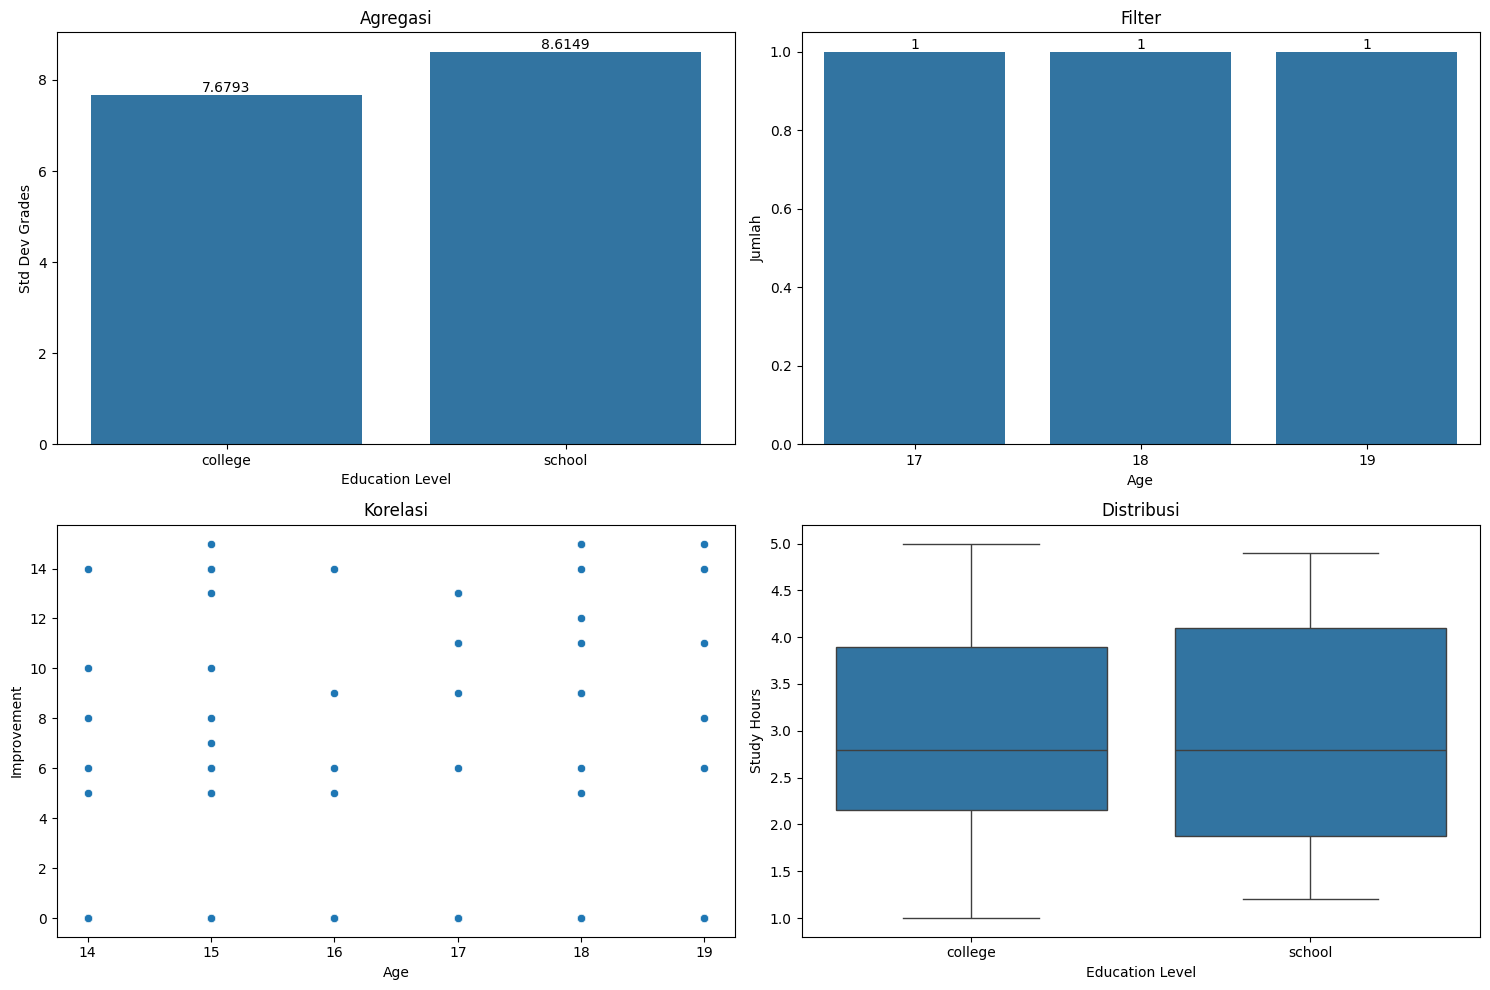

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Grafik A
sns.barplot(
    data=std_edu,
    x='education_level',
    y='grades_after_ai',
    ax=axes[0,0]
)
axes[0,0].set_title('Agregasi')
axes[0,0].set_xlabel('Education Level')
axes[0,0].set_ylabel('Std Dev Grades')

# Menampilkan nilai pada batang
for i, v in enumerate(std_edu['grades_after_ai']):
    axes[0,0].text(
        i, v,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

# Grafik B
sns.barplot(
    data=hasil_b,
    x='age',
    y='jumlah',
    ax=axes[0,1]
)
axes[0,1].set_title('Filter')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Jumlah')

# Menampilkan nilai pada batang
for i, v in enumerate(hasil_b['jumlah']):
    axes[0,1].text(
        i, v,
        str(v),
        ha='center',
        va='bottom'
    )

# Grafik C
sns.scatterplot(
    data=df,
    x='age',
    y='improvement',
    ax=axes[1,0]
)
axes[1,0].set_title('Korelasi')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Improvement')

# Grafik D
sns.boxplot(
    data=df,
    x='education_level',
    y='study_hours_per_day',
    ax=axes[1,1]
)
axes[1,1].set_title('Distribusi')
axes[1,1].set_xlabel('Education Level')
axes[1,1].set_ylabel('Study Hours')

plt.tight_layout()
plt.show()

In [ ]:
#Berdasarkan perhitungan standar deviasi nilai akademik setelah penggunaan AI, kelompok School memiliki standar deviasi lebih tinggi
#(8,6149) dibandingkan College (7,6793). Hal ini menunjukkan bahwa nilai akademik pada jenjang School lebih bervariasi, sedangkan pada
#jenjang College cenderung lebih stabil dan konsisten.

#Proses filtering dilakukan untuk memilih responden dengan jenjang pendidikan College dan nilai grades_after_ai di atas 80. Hasil
#visualisasi menunjukkan distribusi mahasiswa berprestasi berdasarkan tujuan penggunaan AI, yang mengindikasikan bahwa pemanfaatan AI
#sebagai alat bantu belajar dapat mendukung peningkatan performa akademik.

#Analisis korelasi antara umur (age) dan peningkatan nilai (improvement) menghasilkan koefisien sebesar 0,039, yang menunjukkan hubungan
#positif namun sangat lemah. Scatter plot juga memperlihatkan persebaran data yang acak tanpa pola yang jelas, sehingga umur tidak dapat
#dianggap sebagai faktor utama yang memengaruhi peningkatan nilai setelah penggunaan AI.

#Boxplot digunakan untuk membandingkan distribusi jam belajar harian (study_hours_per_day) pada setiap jenjang pendidikan (education_level).
#Median menunjukkan kecenderungan jam belajar tiap kelompok, sedangkan ukuran kotak dan whisker menggambarkan tingkat variasi data.
#Adanya outlier menunjukkan beberapa individu memiliki jam belajar yang jauh berbeda dari mayoritas responden, sehingga boxplot membantu
#mengidentifikasi perbedaan pola belajar antar jenjang pendidikan.